In [1]:
import pandas as pd
import numpy as np
from modulos.data_load import load, coins
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = load('ACMUSDD')
df

,unix,date,symbol,open,high,low,close,Volume ACM,Volume USDD,buyTakerAmount,buyTakerQuantity,tradeCount,weightedAverage
13116,1667174400000,2022-10-31 00:00:00,ACM/USDD,3.308,3.472,3.071,3.233,1186.276103,367.59029,563.989152,173.84448,436,3.228110
13115,1667214000000,2022-10-31 11:00:00,ACM/USDD,3.308,3.466,3.308,3.466,76.177367,22.83042,48.155147,14.42065,42,3.336915
13114,1667217600000,2022-10-31 12:00:00,ACM/USDD,3.374,3.472,3.374,3.472,3.184944,0.91946,3.184944,0.91946,4,3.464008
13113,1667221200000,2022-10-31 13:00:00,ACM/USDD,3.376,3.383,3.346,3.346,7.547714,2.23676,6.352021,1.87941,5,3.374443
13112,1667224800000,2022-10-31 14:00:00,ACM/USDD,3.227,3.227,3.227,3.227,0.118818,0.03682,0.118818,0.03682,1,3.227000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4,1714420800000,2024-04-29 20:00:00,ACM/USDD,4.000,4.000,4.000,4.000,0.000000,0.00000,0.000000,0.00000,0,3.946200
3,1714424400000,2024-04-29 21:00:00,ACM/USDD,4.000,4.000,4.000,4.000,0.000000,0.00000,0.000000,0.00000,0,3.946200
2,1714428000000,2024-04-29 22:00:00,ACM/USDD,4.000,4.000,4.000,4.000,0.000000,0.00000,0.000000,0.00000,0,3.946200
1,1714431600000,2024-04-29 23:00:00,ACM/USDD,4.000,4.000,4.000,4.000,0.000000,0.00000,0.000000,0.00000,0,3.946200


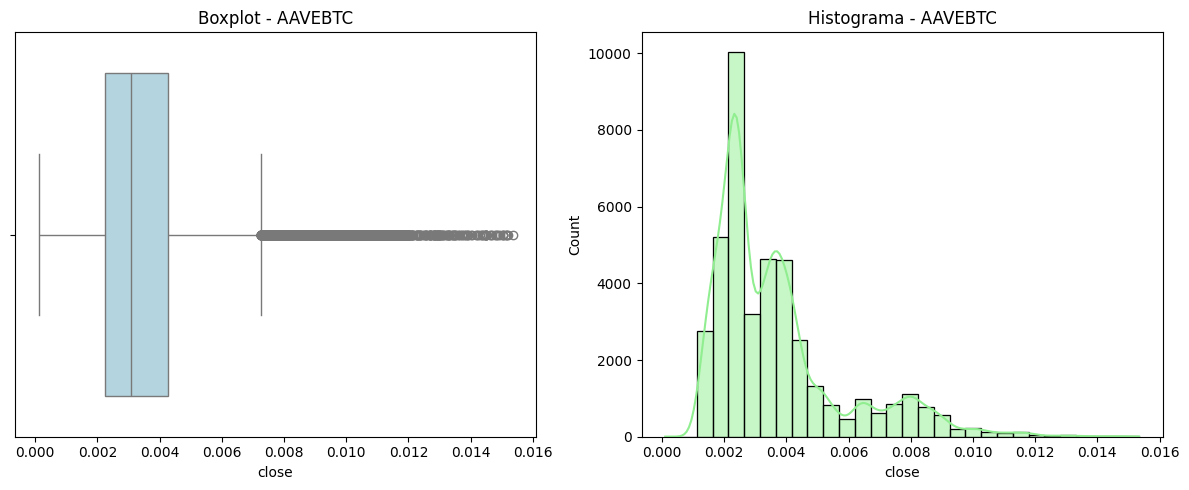

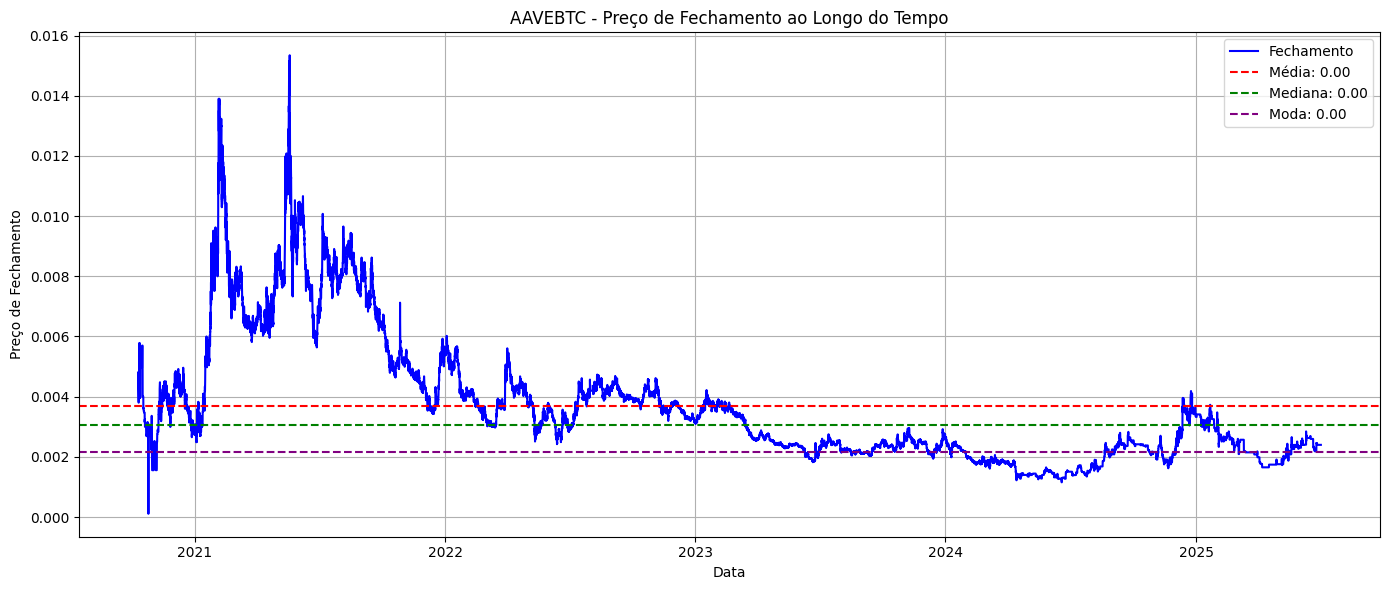

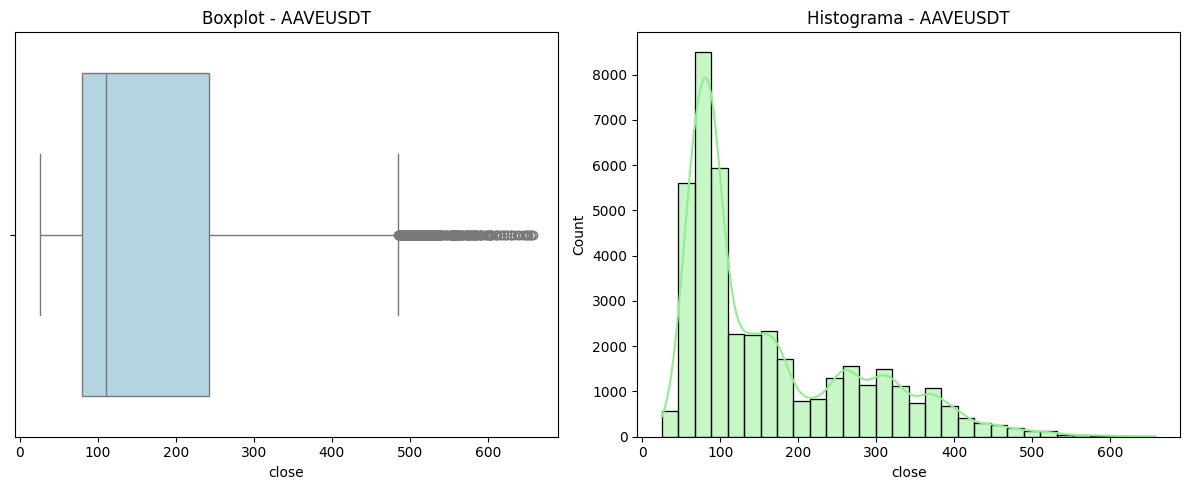

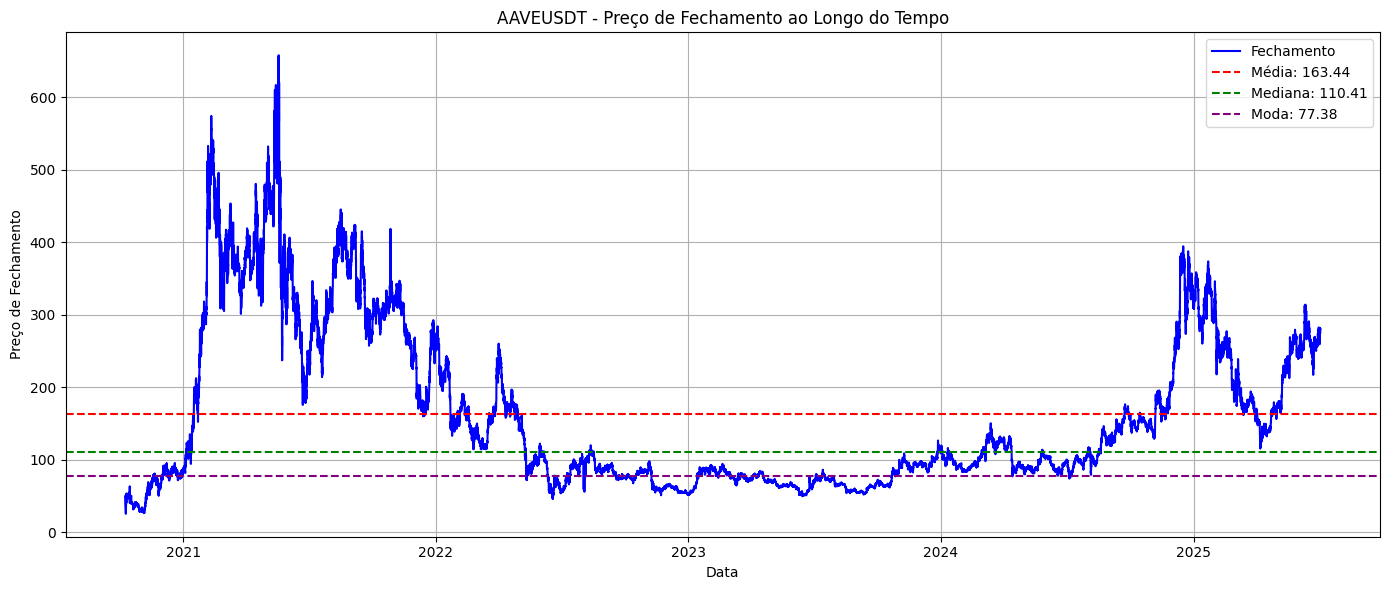

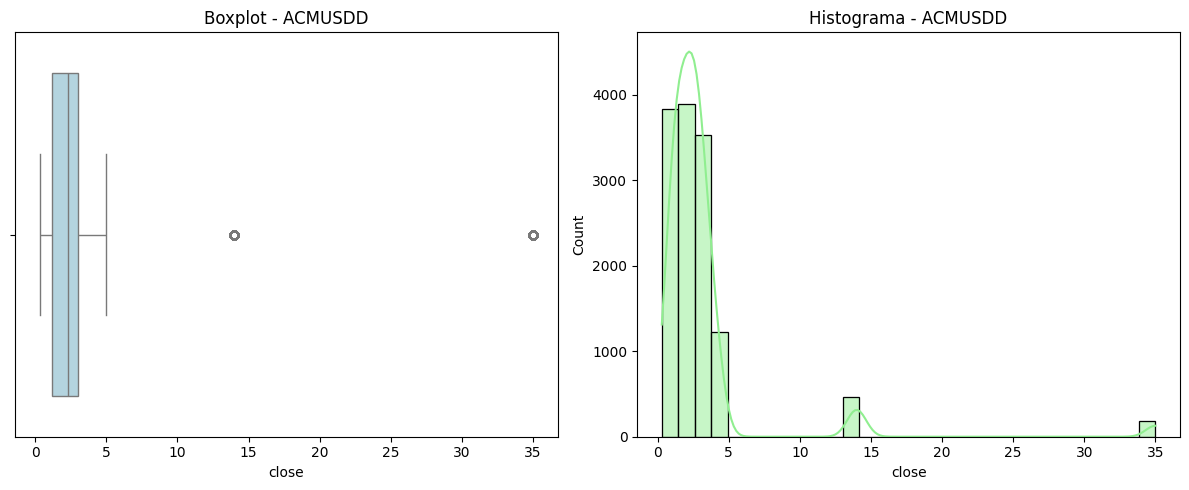

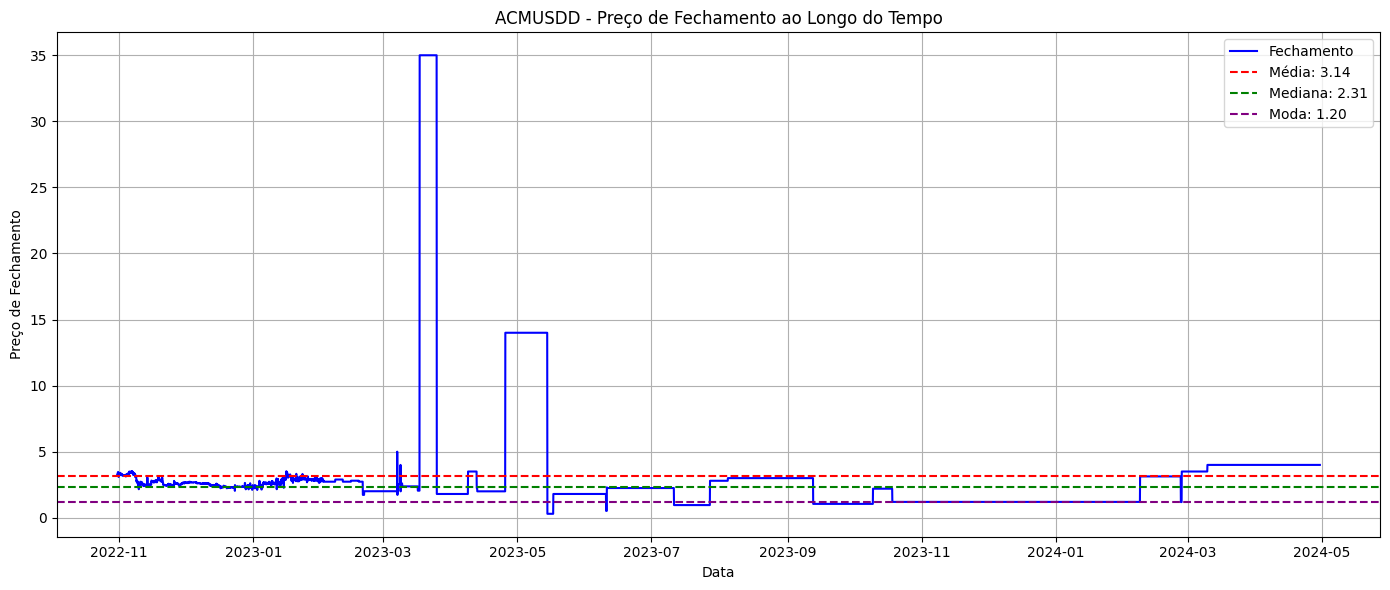

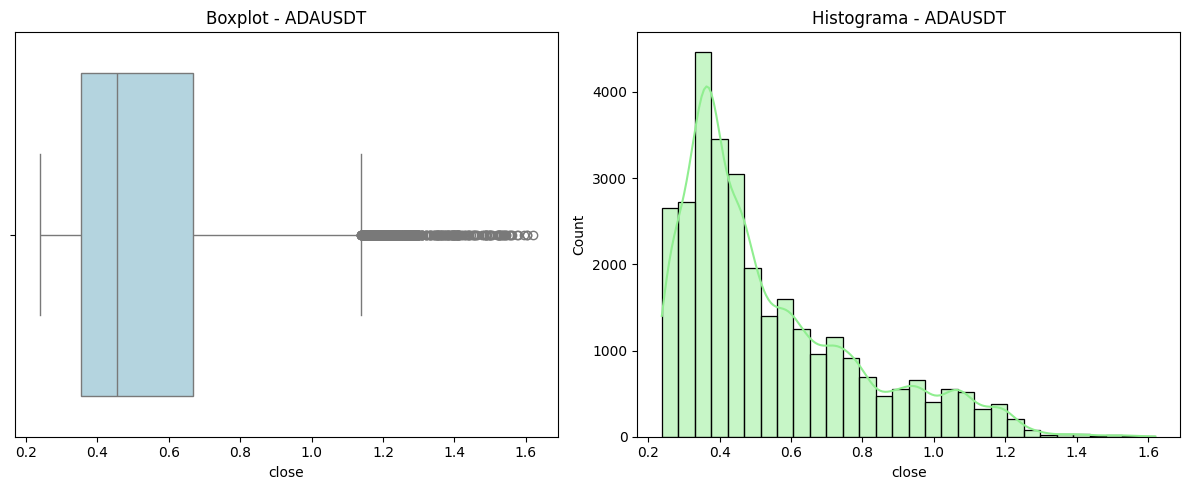

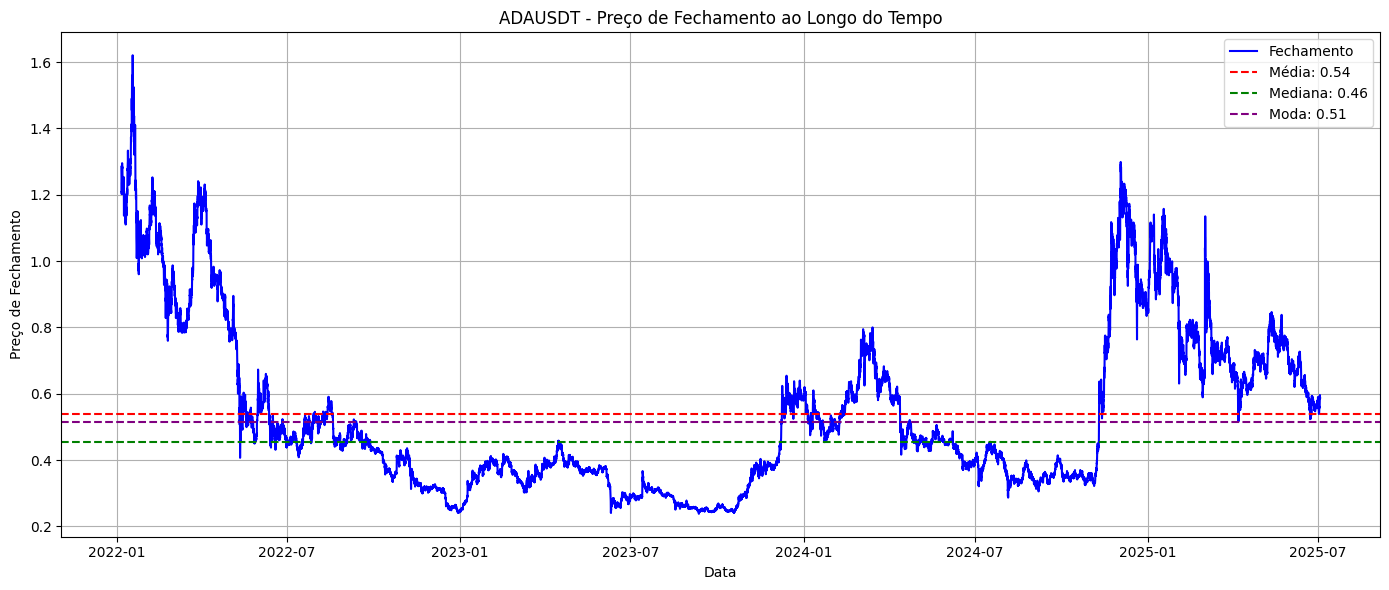

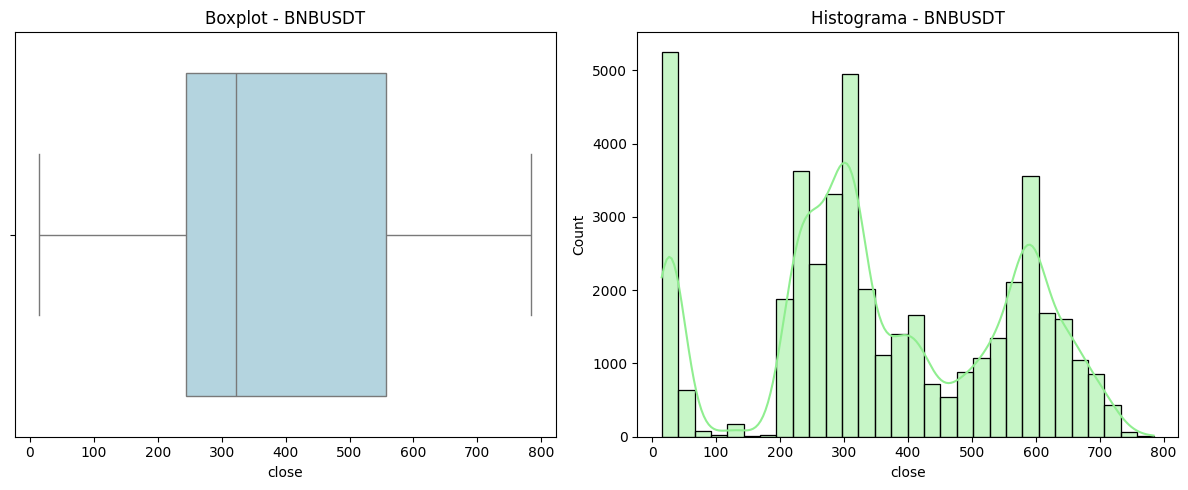

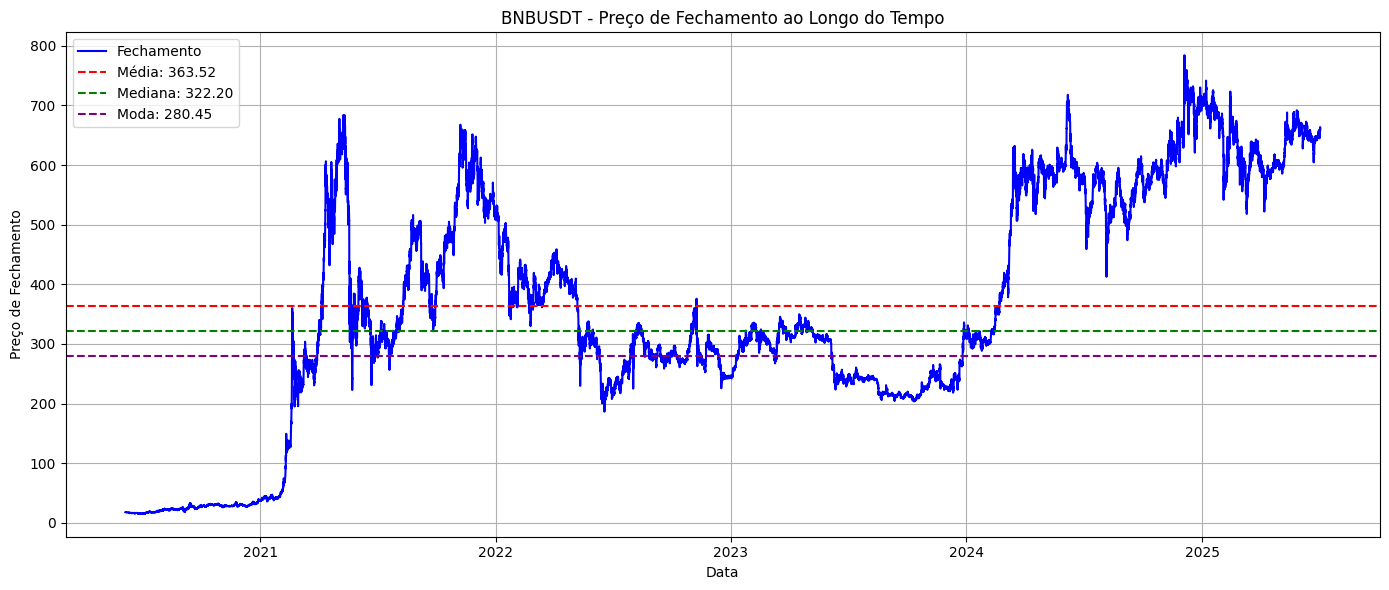

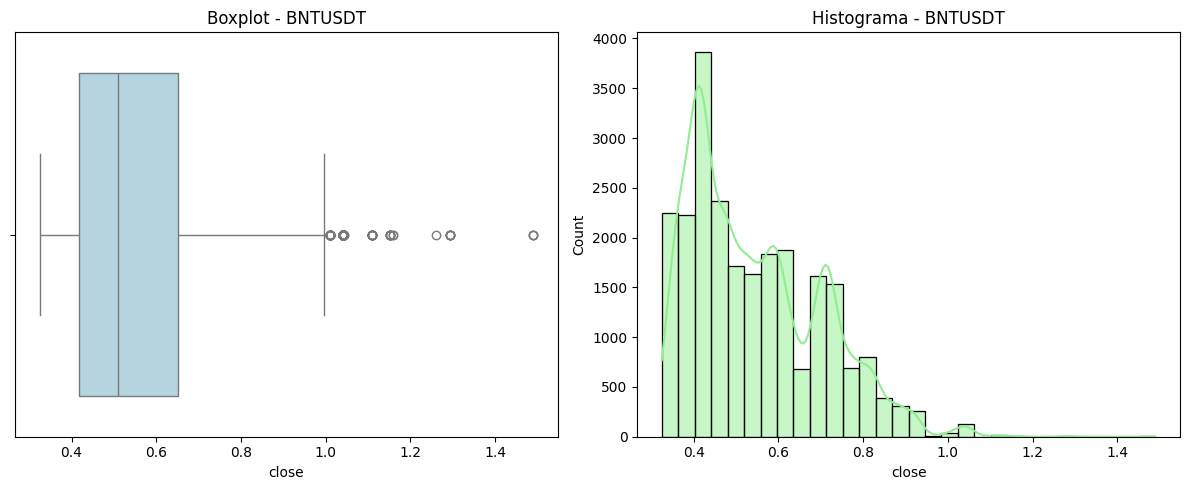

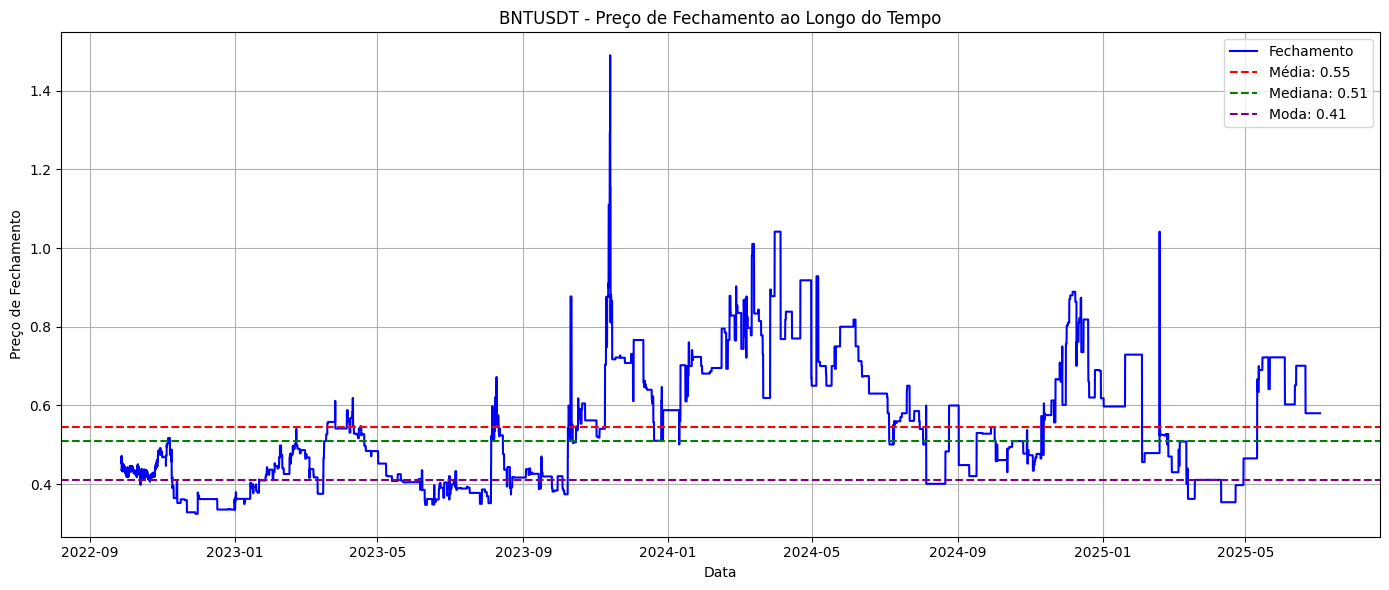

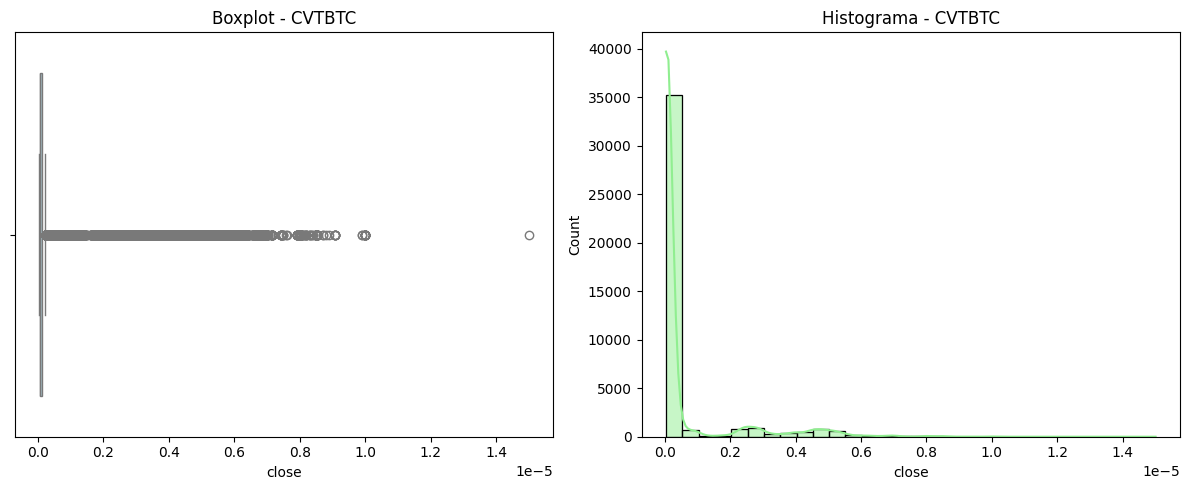

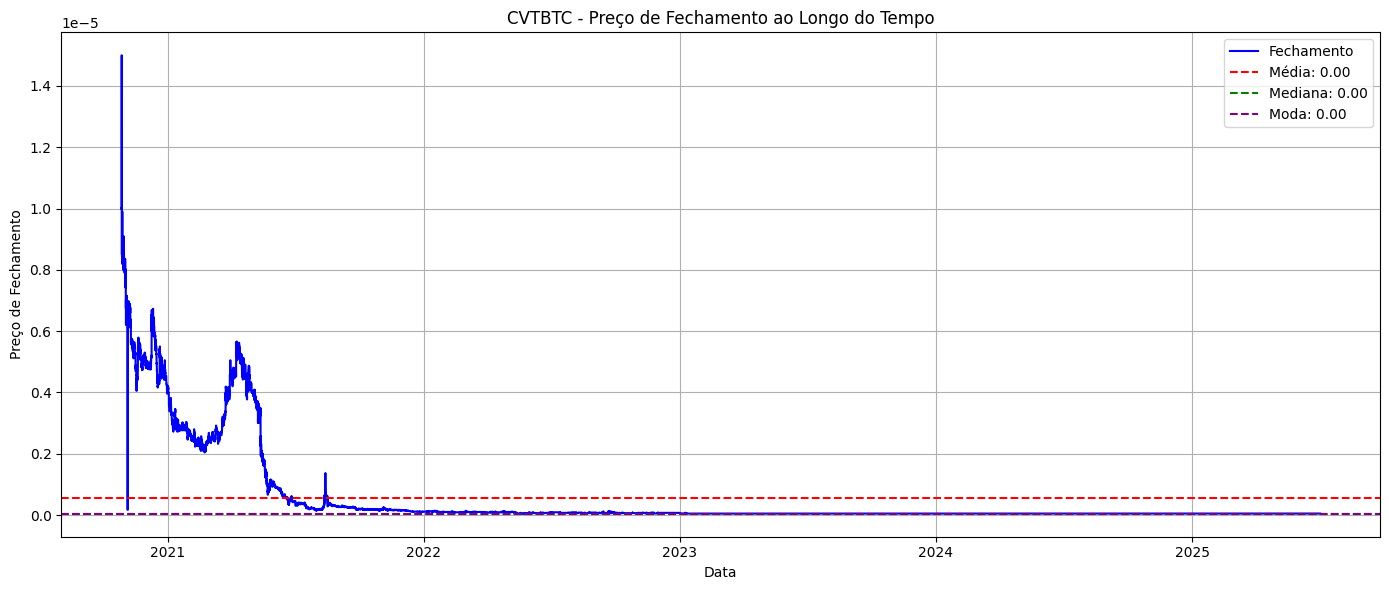

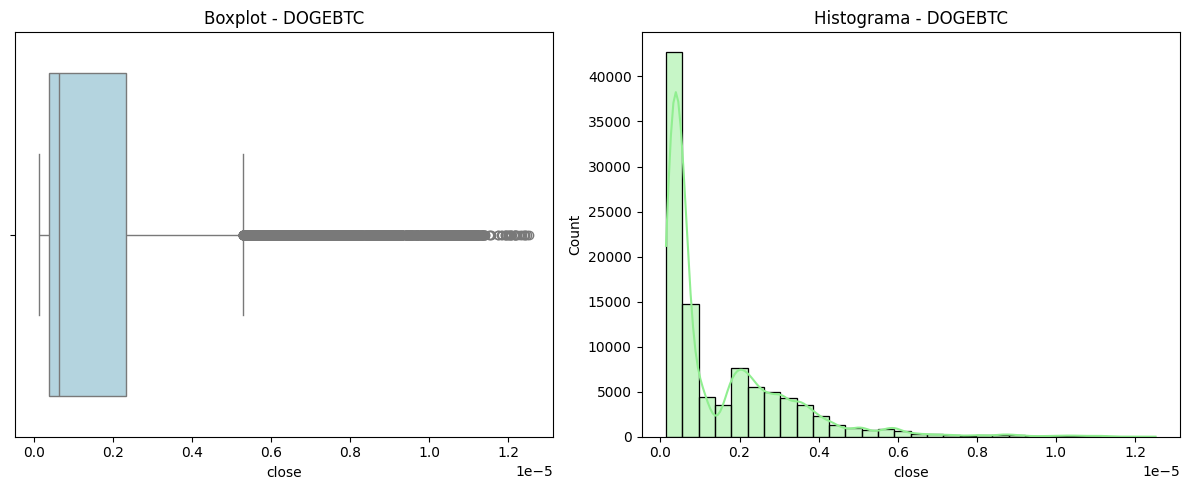

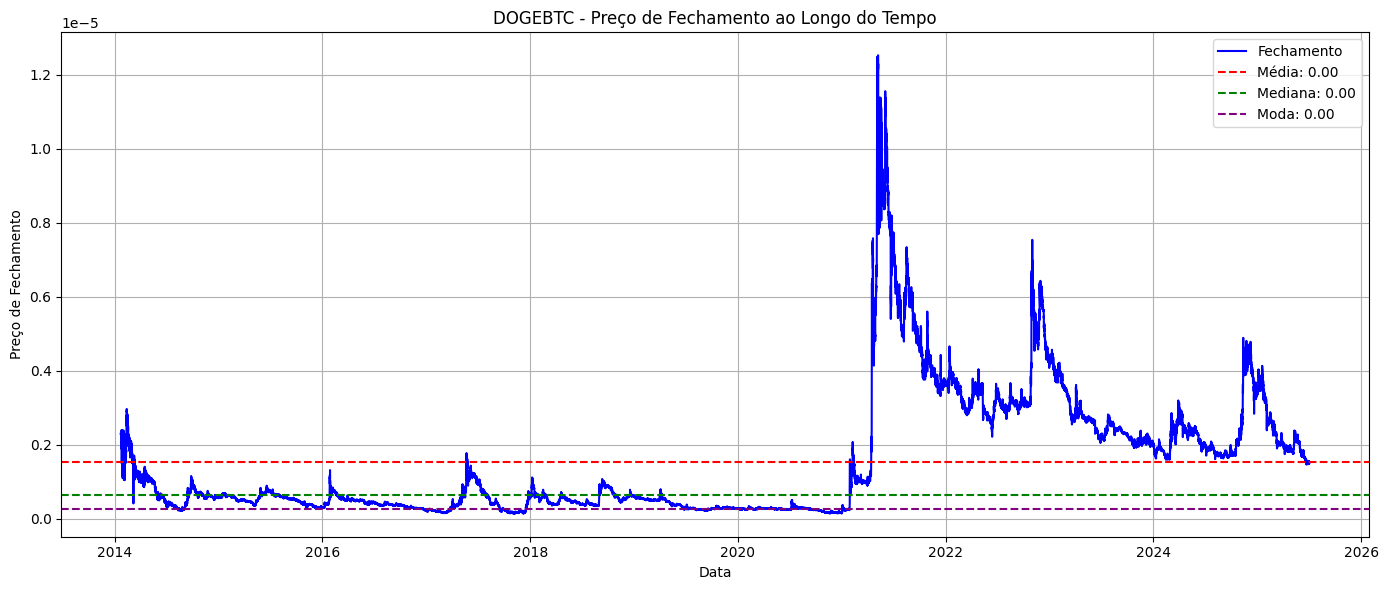

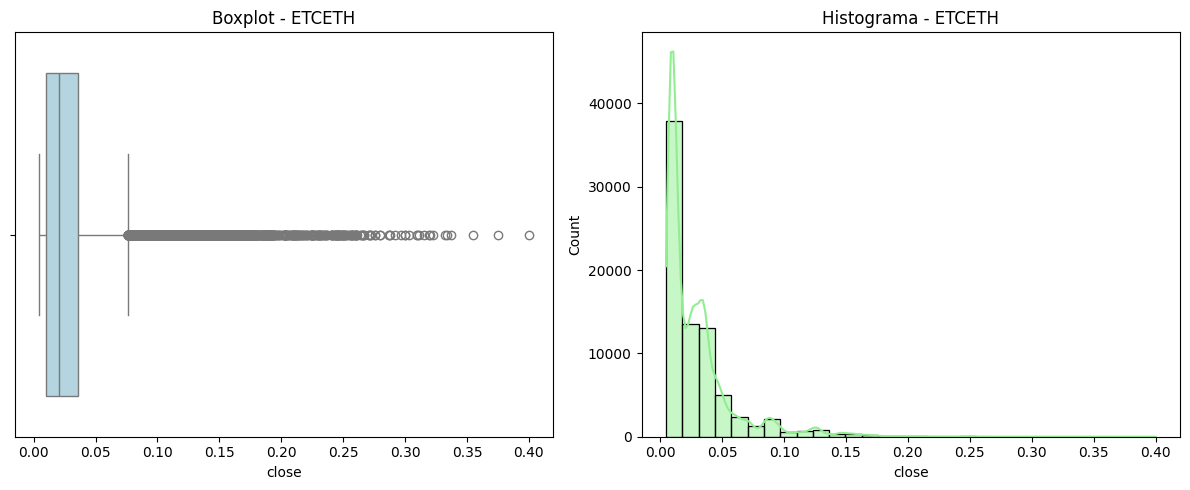

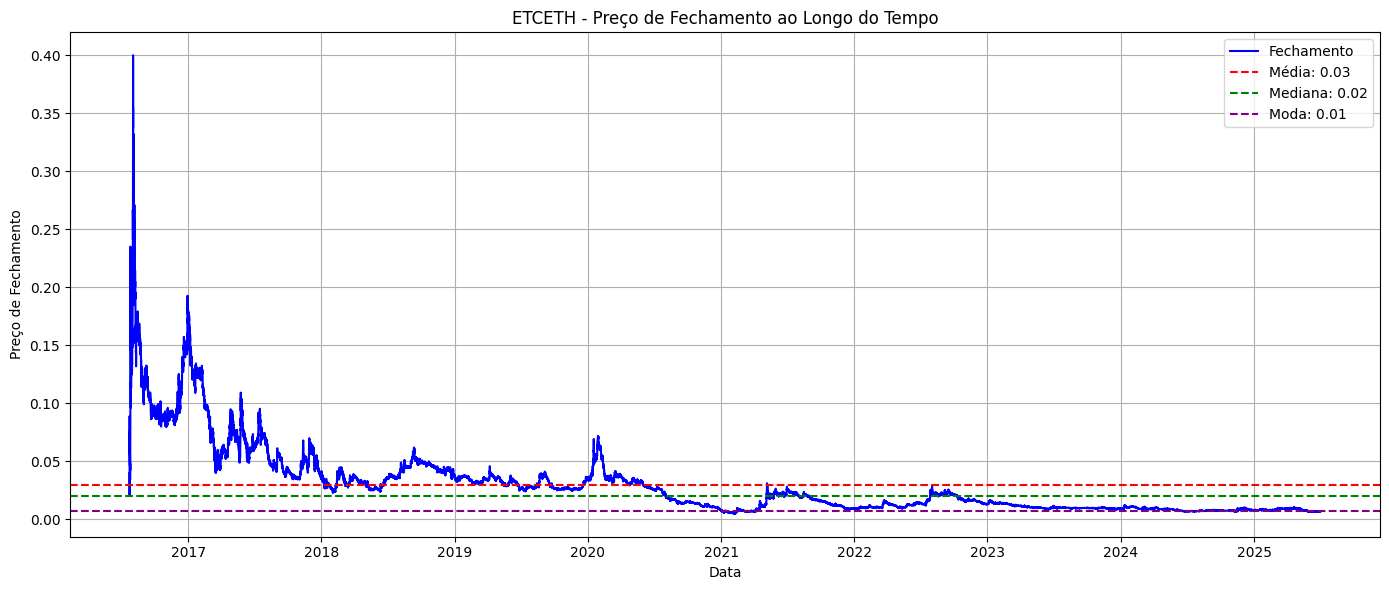

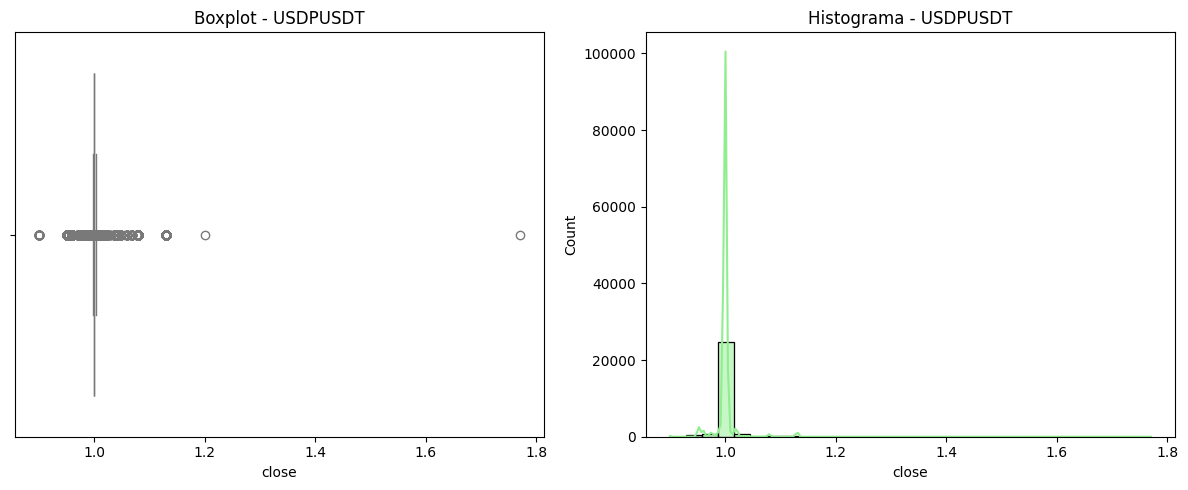

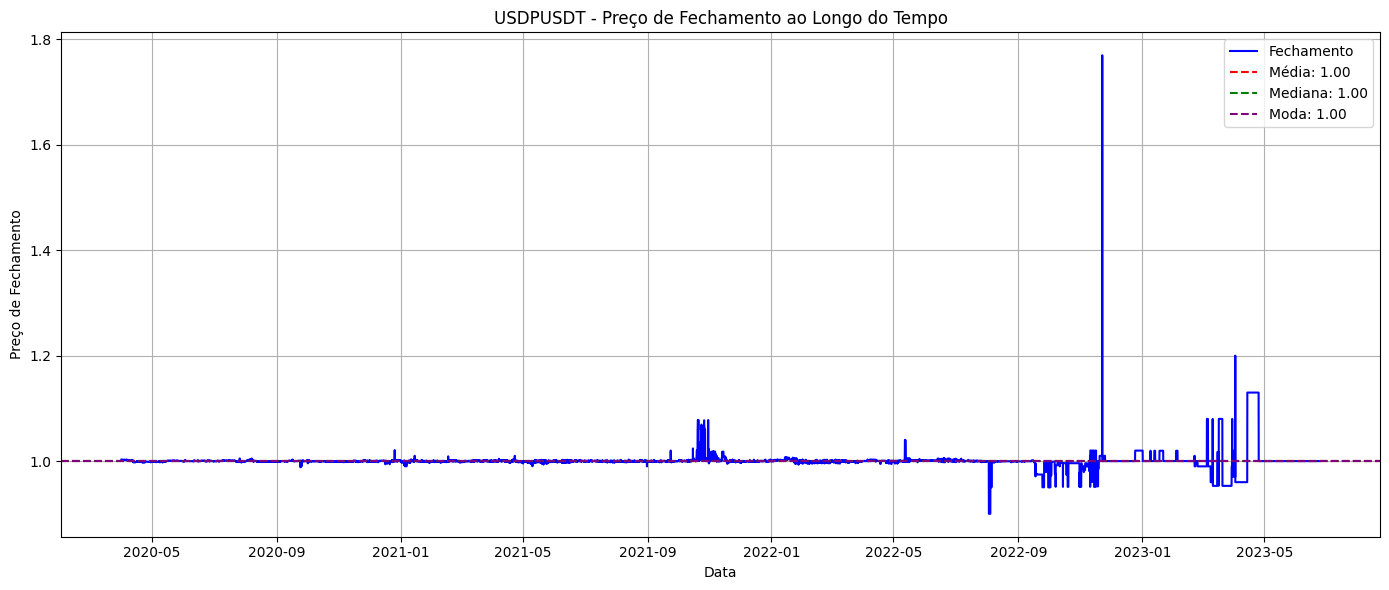

       coin          mean         std           var  coef_var
6    CVTBTC  5.657386e-07    0.000001  1.895662e-12  2.433687
2   ACMUSDD  3.139405e+00    4.492073  2.017872e+01  1.430868
7   DOGEBTC  1.536999e-06    0.000002  2.871653e-12  1.102535
8    ETCETH  2.950968e-02    0.030057  9.034004e-04  1.018534
1  AAVEUSDT  1.634433e+02  112.733058  1.270874e+04  0.689738
0   AAVEBTC  3.699291e-03    0.002133  4.551565e-06  0.576716
4   BNBUSDT  3.635237e+02  196.206016  3.849680e+04  0.539734
3   ADAUSDT  5.382281e-01    0.250335  6.266744e-02  0.465109
5   BNTUSDT  5.452596e-01    0.154596  2.390003e-02  0.283528
9  USDPUSDT  1.000135e+00    0.018314  3.354157e-04  0.018312


In [3]:
results = []

for i, coin in enumerate(coins, start=1):
    df = load(coin).copy()
    df['date'] = pd.to_datetime(df['unix'], unit='ms')
    df.sort_values('date', inplace=True)

    # Etapa A: Medidas resumo e dispersão
    resumo = df['close'].describe()
    variancia = df['close'].var()
    desvio_padrao = df['close'].std()
    coef_var = desvio_padrao / df['close'].mean()

    results.append({
        'coin': coin,
        'mean': resumo['mean'],
        'median': resumo['50%'],
        'mode': df['close'].mode().iloc[0] if not df['close'].mode().empty else None,
        'std': desvio_padrao,
        'var': variancia,
        'coef_var': coef_var
    })

    # Etapa B: Boxplot e Histograma
    plt.figure(figsize=(12, 5))
    
    # Boxplot
    plt.subplot(1, 2, 1)
    sns.boxplot(x=df['close'], color='lightblue')
    plt.title(f'Boxplot - {coin}')

    # Histograma
    plt.subplot(1, 2, 2)
    sns.histplot(df['close'], bins=30, kde=True, color='lightgreen')
    plt.title(f'Histograma - {coin}')
    plt.tight_layout()
    plt.savefig(f"figures/COIN{i}_{coin}_boxplot_hist.png")
    plt.show()

    # Etapa D: Gráfico de linha com média, mediana, moda
    media = resumo['mean']
    mediana = resumo['50%']
    moda = df['close'].mode().iloc[0] if not df['close'].mode().empty else None

    plt.figure(figsize=(14, 6))
    plt.plot(df['date'], df['close'], label='Fechamento', color='blue')
    plt.axhline(media, color='red', linestyle='--', label=f'Média: {media:.2f}')
    plt.axhline(mediana, color='green', linestyle='--', label=f'Mediana: {mediana:.2f}')
    if moda is not None:
        plt.axhline(moda, color='purple', linestyle='--', label=f'Moda: {moda:.2f}')
    plt.title(f'{coin} - Preço de Fechamento ao Longo do Tempo')
    plt.xlabel("Data")
    plt.ylabel("Preço de Fechamento")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"figures/COIN{i}_{coin}_closing_price.png")
    plt.show()

#Etapa C: Comparação entre moedas
df_disp = pd.DataFrame(results)
print(df_disp[['coin', 'mean', 'std', 'var', 'coef_var']].sort_values('coef_var', ascending=False))


